In [ ]:
#required packages
import sys
import os
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sb
import random as rd
import warnings
import tqdm
from tqdm import tqdm
import tabulate

import sklearn
from sklearn.decomposition import PCA
from google.colab import drive
from google.colab import files

#mount to gdrive
drive.mount('/content/gdrive')
gdrive_path = '/content/gdrive/MyDrive/REVEAL_UCSF_project/chemical_database_list'
gdrive_path2 = '/content/gdrive/MyDrive/REVEAL_UCSF_project/First400'
gdrive_path4 = '/content/gdrive/MyDrive/REVEAL_UCSF_project/chemical_database_list'

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
from tqdm import tqdm
import tabulate
peakarea_path = [os.path.join(gdrive_path2, "pos_Area_1_2025_06_12_14_43_23_updated.csv")]
QACs_path = [os.path.join(gdrive_path4,'QACs_chemical_list_comptox_March09.csv')]

#load peak area
pos_peak_area = pd.read_csv(peakarea_path[0])
QACs_mz = pd.read_csv(QACs_path[0])

In [ ]:
#exact mass search
targetmzdat_pos = QACs_mz.copy()
targetmzdat_pos['mz'] = targetmzdat_pos['Exact_mass']

# Select relevant columns for inquiry
peak_area_inquiry = pos_peak_area[['Average Rt(min)', 'Average Mz'] + [col for col in pos_peak_area.columns if col.startswith('BH')]]
print(len([col for col in peak_area_inquiry.columns if col.startswith('BH')]))

ppm_threshold = 20
matched_rows_pos = []
matched_summary = []

# Function to calculate ppm difference
def ppm_difference(value1, value2):
    return abs(value1 - value2) / value1 * 1e6

# MS1 search and matching
for _, chem_row in tqdm(targetmzdat_pos.iterrows(), total=targetmzdat_pos.shape[0], desc="Matching compounds"):
    mw = chem_row['mz']
    RT = chem_row['RT2']
    matches = peak_area_inquiry[peak_area_inquiry['Average Mz'].apply(lambda mz: ppm_difference(mz, mw) <= ppm_threshold)]
    #filter matches by RT differences = Average RT - RT2
    #matches = matches[matches['Average Rt(min)'].apply(lambda rt: abs(rt - RT) <= 0.8)]

    if not matches.empty:
        # Append the matches along with the corresponding compound information
        for _, match_row in matches.iterrows():
            matched_rows_pos.append({
                **match_row,
                'Matched Compound': chem_row['SMILES'],
                'PREFERRED_NAME': chem_row.get('PREFERRED_NAME', None),
                'DTXSID': chem_row.get('DTXSID', None),
                'InChiKey_origin': chem_row.get('INCHIKEY', None),
                'MOLECULAR_FORMULA_original': chem_row.get('MOLECULAR_FORMULA', None),
                'SMILES_STD': chem_row.get('MS_READY_SMILES', None),
                "Monoisotopic_mass_ready": chem_row.get('MONOISOTOPIC_MASS', None)
            })

# convert to data frame for data imputation
matched_peak_area_df_pos = pd.DataFrame(matched_rows_pos)
# drop rows with duplicated column values at Average Rt(min) and Average Mz, retaining the first occurrence
matched_peak_area_df_pos_uniquemzrt = matched_peak_area_df_pos.drop_duplicates(subset=['Average Rt(min)', 'Average Mz'], keep='first')
# Step 3: Handling technical duplicates and calculating mean values
bh_columns = [col for col in matched_peak_area_df_pos.columns if col.startswith('BH')]

# 1. Create a dictionary to hold our grouped data
grouped_samples = {}

# 2. Iterate through columns and group them cleanly
for col in bh_columns:
    # Split at the first underscore and remove ANY trailing/leading spaces or split at the first ' ' and take the first element
    base_col = col.split('_')[0].strip()
    if base_col not in grouped_samples:
        grouped_samples[base_col] = []

    grouped_samples[base_col].append(col)

# 3. Calculate the mean for each unique sample
mean_columns = {}
for base_col, replicate_cols in grouped_samples.items():
    # Calculate the mean across the replicates for this specific sample
    mean_columns[base_col] = matched_peak_area_df_pos[replicate_cols].mean(axis=1)

mean_columns_df = pd.DataFrame(mean_columns)

# 4. Drop the old messy columns and attach the newly averaged ones
matched_peak_area_df_pos = matched_peak_area_df_pos.drop(columns=bh_columns)
matched_peak_area_df_pos = pd.concat([matched_peak_area_df_pos, mean_columns_df], axis=1)
print(f"Total columns starting with 'BH' now attached to df: {len([col for col in matched_peak_area_df_pos.columns if col.startswith('BH')])}")

bh_columns = [col for col in matched_peak_area_df_pos.columns if col.startswith('BH')]
print(f'Original sample columns (with replicates): {len(bh_columns)}')

#output the matched peak area data
matched_peak_pos = matched_peak_area_df_pos.sort_values(by=['Average Rt(min)', 'Average Mz'])
matched_peak_pos.to_csv(os.path.join(gdrive_path2,"matched_peak_area_database_pos_QACs_0309.csv"))

# Count the number of retained columns after intensity filtering
num_retained_columns = matched_peak_pos.shape[1]
print(f"Number of columns retained after intensity filtering: {num_retained_columns}")
print(f'dimension of the filtered data: {matched_peak_pos.shape}')

# Create a DataFrame from the summary statistics
summary_stats_df_pos = pd.DataFrame(matched_peak_pos)
# summary_stats_df_pos.to_csv(os.path.join(gdrive_path2,'mathced_peaks_summary_forallsamples_pos_QACs_0309.csv')) #this is match for standards without RT

800


Matching compounds: 100%|██████████| 49/49 [00:01<00:00, 42.76it/s]


Total columns starting with 'BH' now attached to df: 400
Original sample columns (with replicates): 400
Number of columns retained after intensity filtering: 409
dimension of the filtered data: (231, 409)


In [ ]:
# --------------------------------------------------
# Step 1: retrieve original peak area rows correctly by 'Alignment ID'
# --------------------------------------------------
meta_info = [os.path.join(gdrive_path2, 'pos_column2_manualupdate_withinjection.csv')]
meta_info = pd.read_csv(meta_info[0])
if 'Alignment ID' in matched_peak_pos.columns and 'Alignment ID' in pos_peak_area.columns:
    original_pos_peak_area = pos_peak_area[
        pos_peak_area['Alignment ID'].isin(matched_peak_pos['Alignment ID'])
    ].copy()

    # keep the same order as matched_peak_pos
    original_pos_peak_area = (
        matched_peak_pos[['Alignment ID']]
        .merge(original_pos_peak_area, on='Alignment ID', how='left')
    )
else:
    original_pos_peak_area = pos_peak_area.iloc[matched_peak_pos.index].copy()

# --------------------------------------------------
# Step 2: batch-wise blank subtraction using meta_info
# --------------------------------------------------
# meta_info must contain: Sample, Batch, Injection_order
required_meta_cols = ['Sample', 'Batch', 'Injection_order']

meta_info['Sample'] = meta_info['Sample'].astype(str)
meta_info['Batch'] = meta_info['Batch'].astype(str)

# identify BH samples and DI blanks from meta_info
bh_samples = meta_info.loc[meta_info['Sample'].str.startswith('BH'), 'Sample'].tolist()
di_blanks = meta_info.loc[meta_info['Sample'].str.startswith('DI'), 'Sample'].tolist()

# keep only columns that actually exist in the peak area table
bh_samples = [c for c in bh_samples if c in original_pos_peak_area.columns]
di_blanks = [c for c in di_blanks if c in original_pos_peak_area.columns]

# convert sample columns to numeric
sample_cols = bh_samples + di_blanks
for col in sample_cols:
    original_pos_peak_area[col] = pd.to_numeric(original_pos_peak_area[col], errors='coerce')

# preserve metadata columns
non_sample_cols = [c for c in original_pos_peak_area.columns if c not in sample_cols]
corrected_pos_peak_area = original_pos_peak_area.copy()

# subtract mean DI blank within each batch from each BH sample in the same batch
for batch_name, batch_df in meta_info.groupby('Batch'):
    batch_samples = batch_df['Sample'].tolist()
    batch_bh = [s for s in batch_samples if s.startswith('BH') and s in corrected_pos_peak_area.columns]
    batch_di = [s for s in batch_samples if s.startswith('DI') and s in corrected_pos_peak_area.columns]
    # row-wise mean blank for this batch
    batch_blank_mean = corrected_pos_peak_area[batch_di].mean(axis=1)
    # subtract from each BH sample in this batch
    corrected_pos_peak_area[batch_bh] = corrected_pos_peak_area[batch_bh].sub(batch_blank_mean, axis=0)

# set negative values to 0
corrected_pos_peak_area[bh_samples] = corrected_pos_peak_area[bh_samples].clip(lower=0)

print(f'corrected_pos_peak_area shape: {corrected_pos_peak_area.shape}')
print(tabulate.tabulate(corrected_pos_peak_area.head(), headers='keys', tablefmt='psql', showindex=False))

corrected_pos_peak_area shape: (231, 967)
+----------------+-------------------+--------------+-------------------+---------------+------------------------+----------+------------------+----------------+-----------------+-----------+------------+------------+----------+--------------------------+--------------+---------------+-----------------+----------------------------+----------------------------------------+------------------------------------+------------------------------+----------------------------------+-----------------+------------------+----------------------+------------------------+-----------------------+-----------------------+----------------------------+---------------+---------------+--------------------------------+------------------------------------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+---------------

In [ ]:
#get BH sample columns and caluclate detection frequency
bh_columns = [col for col in corrected_pos_peak_area.columns if col.startswith('BH')]
grouped_samples = {}
for col in bh_columns:
    # Split at the first underscore and remove ANY trailing/leading spaces
    base_col = col.split('_')[0].strip()
    if base_col not in grouped_samples:
        grouped_samples[base_col] = []
    grouped_samples[base_col].append(col)

mean_columns = {}
for base_col, replicate_cols in grouped_samples.items():
    # Calculate the mean across the replicates for this specific sample
    mean_columns[base_col] = corrected_pos_peak_area[replicate_cols].mean(axis=1)

mean_columns_df = pd.DataFrame(mean_columns)

# Drop the old messy columns and attach the newly averaged ones
corrected_average_peak_area = corrected_pos_peak_area.drop(columns=bh_columns)
corrected_average_peak_area = pd.concat([corrected_average_peak_area, mean_columns_df], axis=1)
print(f"Total columns starting with 'BH' now attached to df: {len([col for col in corrected_average_peak_area.columns if col.startswith('BH')])}")

#calculate the detection frequency for each row -- each feature
    #detection frequency = number of peak area >= 5000 / totoal number of sample columns *100
corrected_average_peak_area['Detection frequency'] = (
    corrected_average_peak_area[[col for col in corrected_average_peak_area.columns if col.startswith('BH')]]
    .ge(1000)
    .sum(axis=1)
    .div(len(bh_columns))
    .mul(100)
)

#mutate a column 'feature_id' = str(Average Mz)_str(Average Rt(min))
corrected_average_peak_area['feature_id'] = corrected_average_peak_area['Average Mz'].astype(str) + '_' + corrected_average_peak_area['Average Rt(min)'].astype(str)

#summary of the detection frequency value and print it by tabulate.tabulate
print(corrected_average_peak_area['Detection frequency'].describe())

Total columns starting with 'BH' now attached to df: 400
count    231.000000
mean      23.481061
std       15.114449
min        0.000000
25%        9.875000
50%       23.250000
75%       34.687500
max       50.000000
Name: Detection frequency, dtype: float64


In [ ]:
#output corrected average peak area table for downstream anlaysis
corrected_average_peak_area.to_csv(os.path.join(gdrive_path2,"corrected_average_peak_area_pos_QACs_0505.csv"))

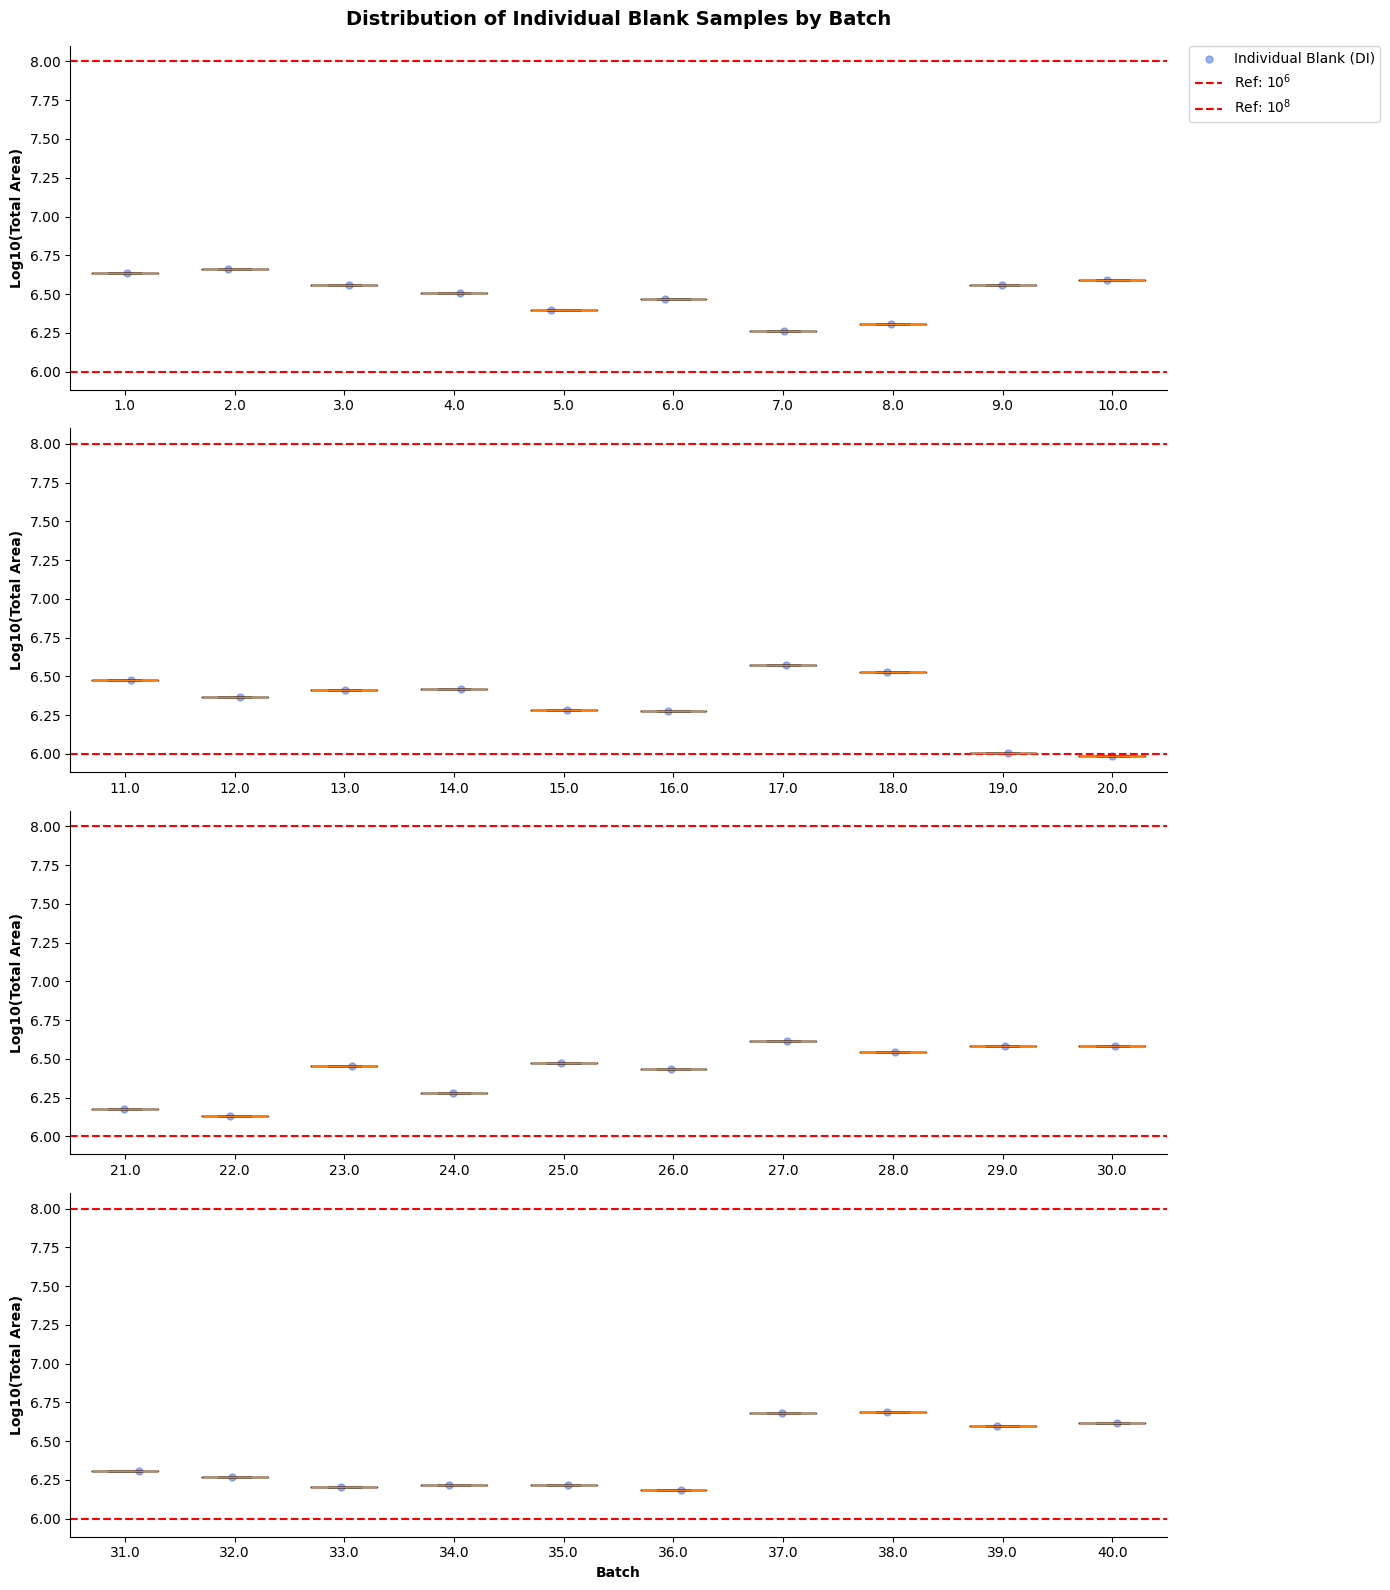

Plot successfully saved to:
/content/gdrive/MyDrive/REVEAL_UCSF_project/First400/per_sample_area_blanks_log10.png



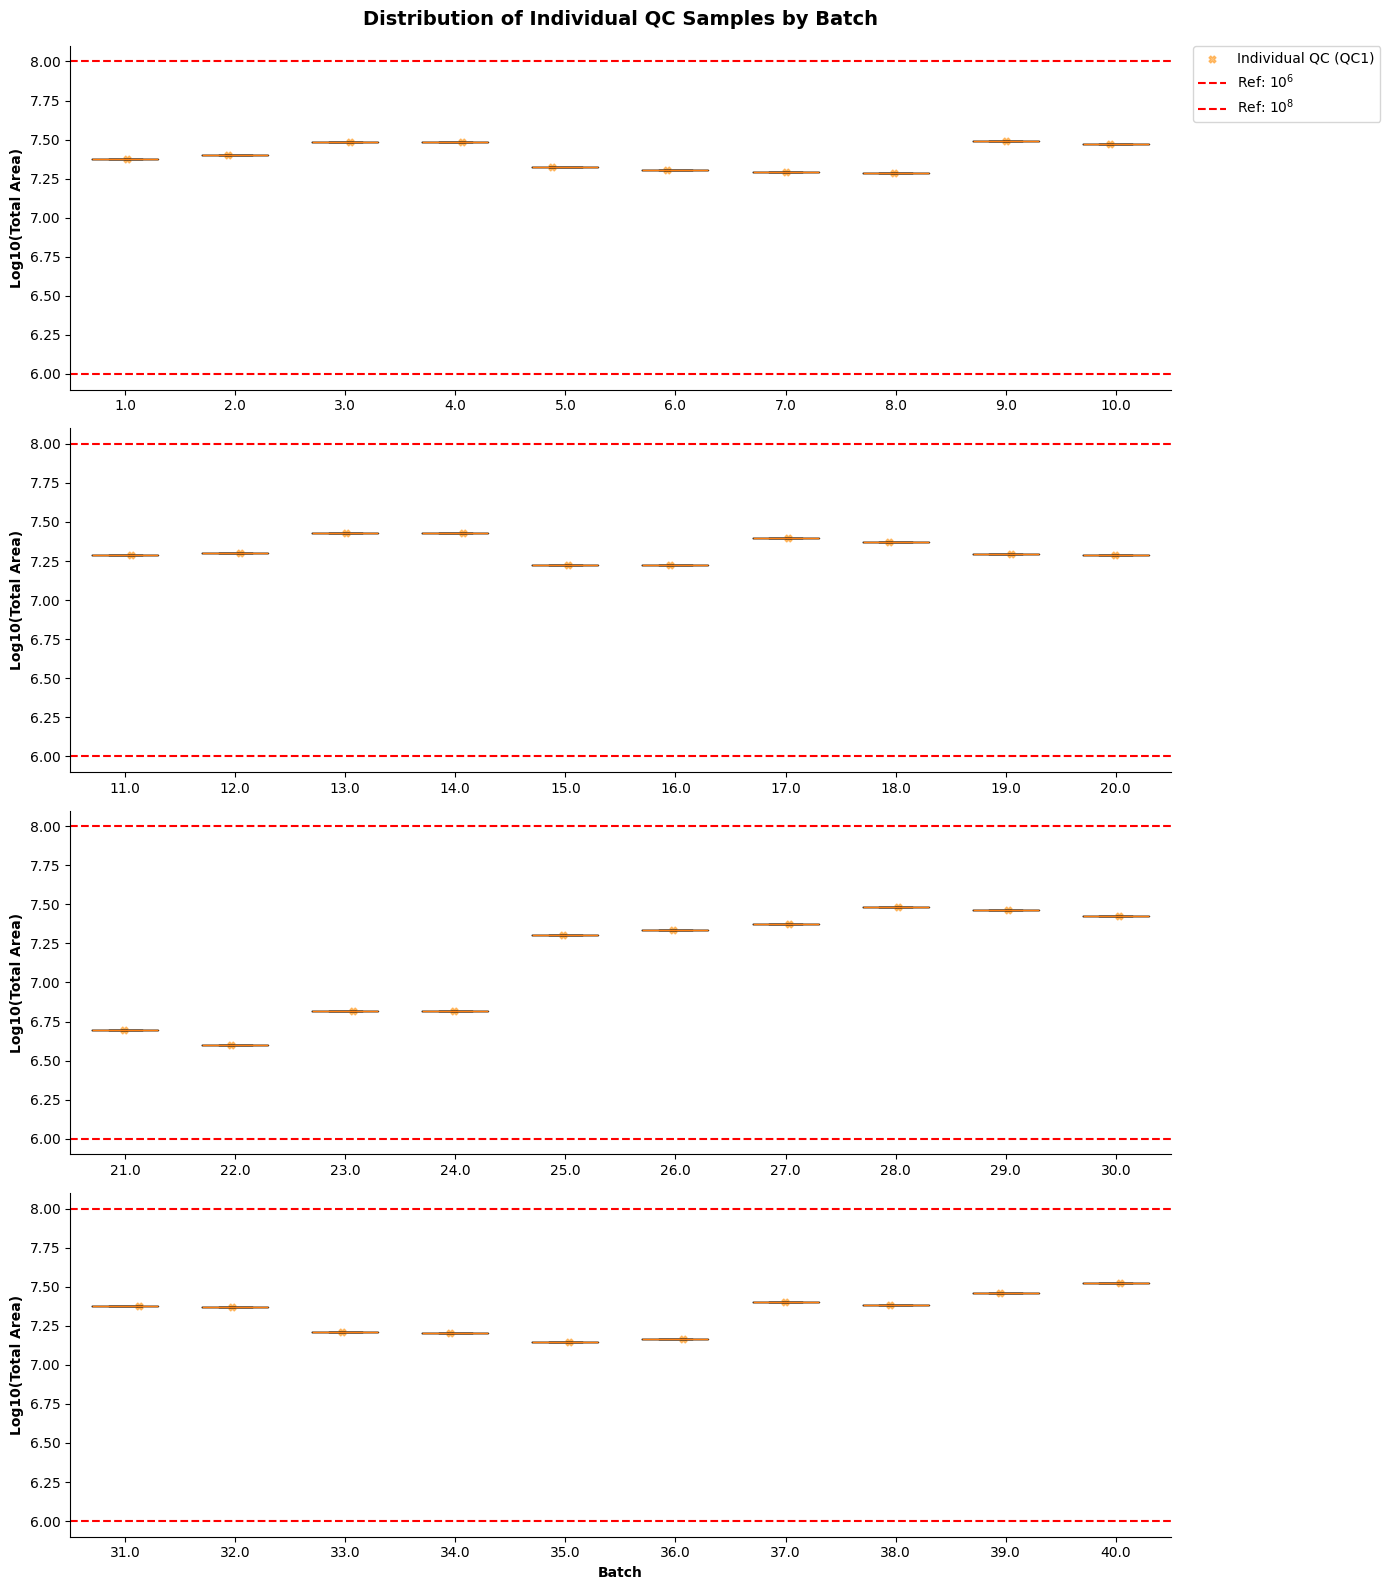

Plot successfully saved to:
/content/gdrive/MyDrive/REVEAL_UCSF_project/First400/per_sample_area_qc_log10.png



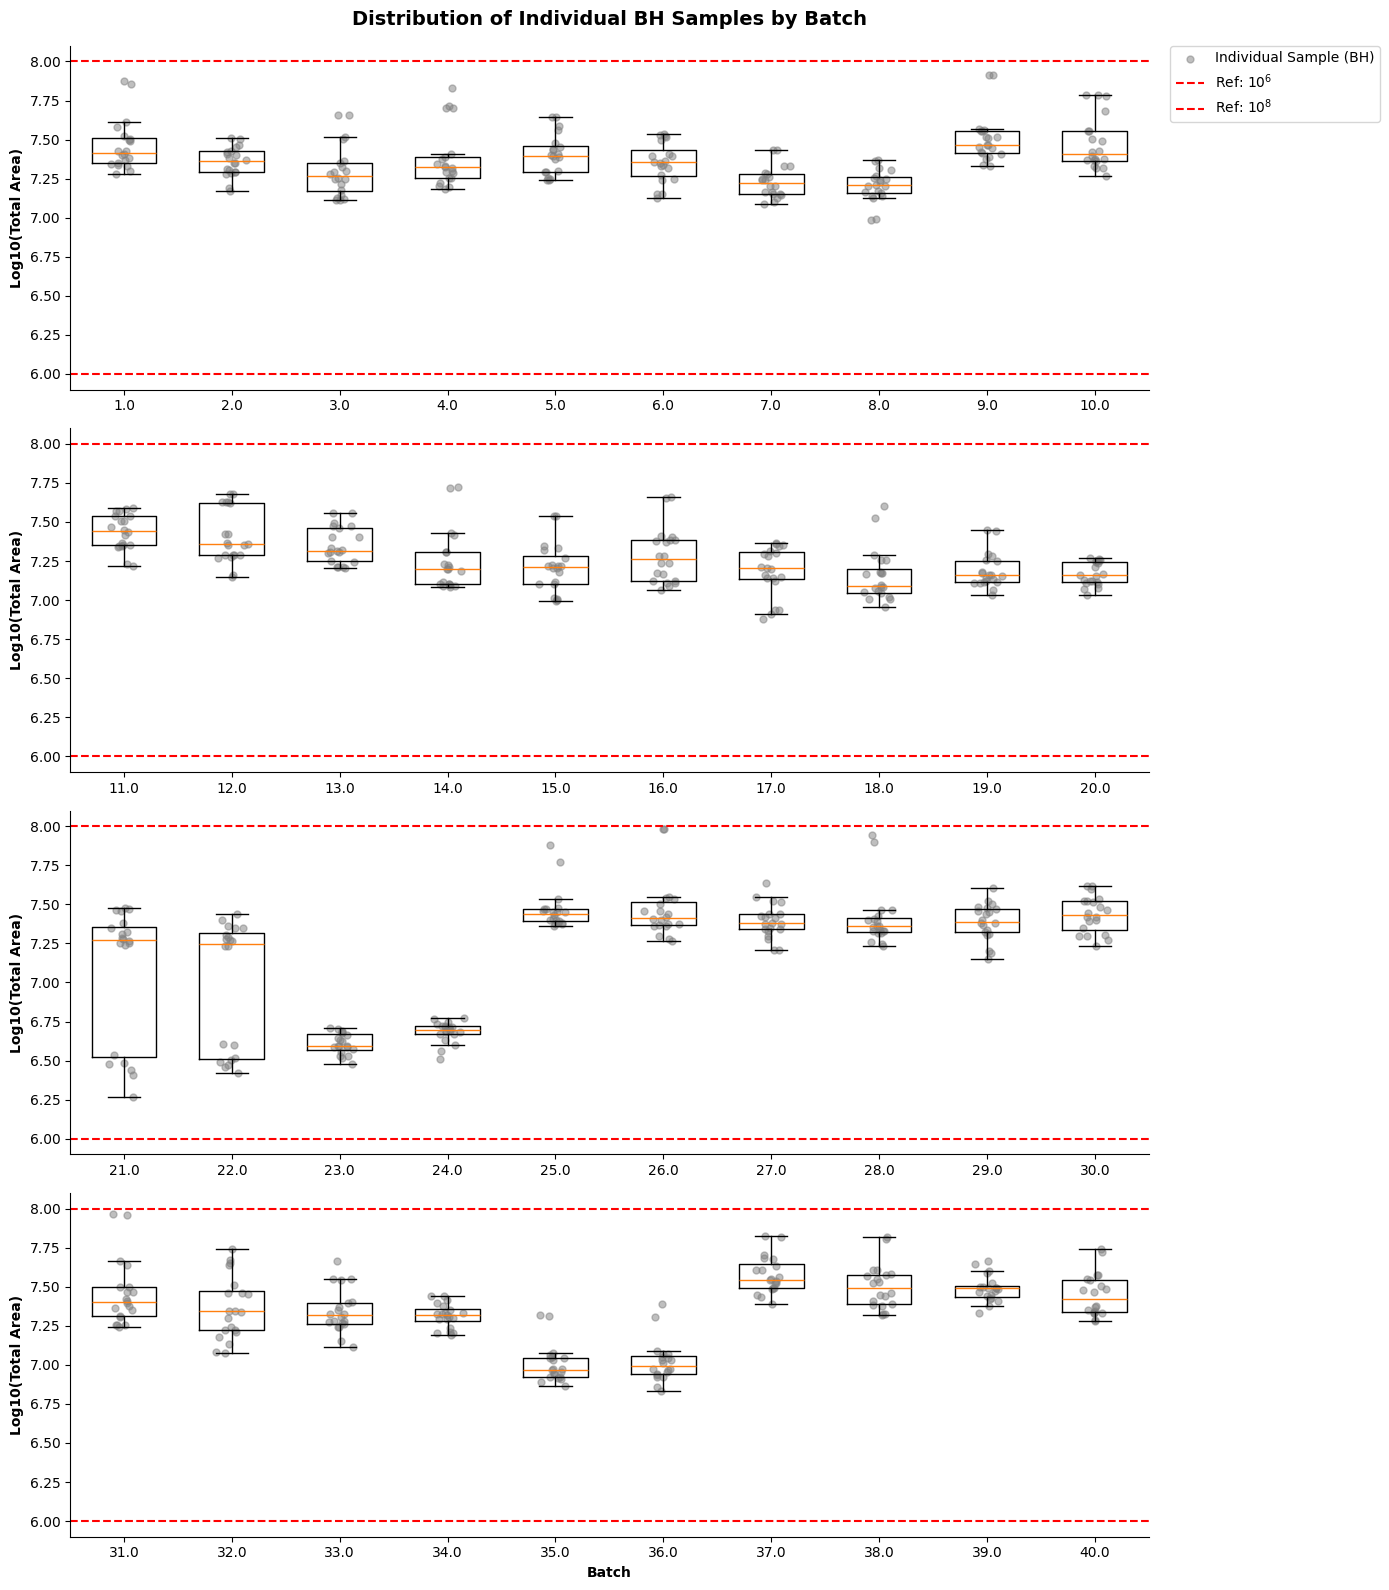

Plot successfully saved to:
/content/gdrive/MyDrive/REVEAL_UCSF_project/First400/per_sample_area_bh_log10.png



In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# --------------------------------------------------
# Step 1: Calculate the Feature Sum for EACH Sample
# --------------------------------------------------
sample_sums = corrected_pos_peak_area.sum(axis=0).reset_index()
sample_sums.columns = ['Sample', 'per_sample_sum_area']

# Merge with meta_info
plot_df = pd.merge(sample_sums, meta_info[['Sample', 'Batch']], on='Sample', how='inner')

plot_df['Sample_Type'] = 'Other'
plot_df.loc[plot_df['Sample'].str.startswith('BH'), 'Sample_Type'] = 'Sample (BH)'
plot_df.loc[plot_df['Sample'].str.startswith('DI'), 'Sample_Type'] = 'Blank (DI)'
plot_df.loc[plot_df['Sample'].str.startswith('QC1'), 'Sample_Type'] = 'QC (QC1)'

# --- THE FIX: Force strict numeric types to prevent NumPy log10 errors ---
plot_df['per_sample_sum_area'] = pd.to_numeric(plot_df['per_sample_sum_area'], errors='coerce')

# Drop any NaNs and ensure values are strictly positive for log-scale plotting
plot_df = plot_df.dropna(subset=['per_sample_sum_area'])
plot_df = plot_df[plot_df['per_sample_sum_area'] > 0]

# Now safely apply the Log10 Transform
plot_df['log10_area'] = np.log10(plot_df['per_sample_sum_area'].astype(float))

# --------------------------------------------------
# Step 2: Reusable Grid Plotting Function
# --------------------------------------------------
def build_grid_plot(data, sample_type_label, plot_title, filename, point_color, ref_lines=None, point_marker='o', save_directory=gdrive_path2):

    if ref_lines is None:
        ref_lines = []

    df_sub = data[data['Sample_Type'] == sample_type_label].copy()

    if df_sub.empty:
        print(f"Warning: No positive data found for {sample_type_label}. Skipping plot.")
        return

    def extract_batch_number(x):
        import re
        nums = re.findall(r'\d+', str(x))
        return int(nums[0]) if nums else np.nan

    batch_order = (
        df_sub[['Batch']]
        .drop_duplicates()
        .assign(batch_num=lambda df: df['Batch'].apply(extract_batch_number))
        .sort_values('batch_num')
        ['Batch']
        .tolist()
    )

    batches_per_row = 10
    num_rows = math.ceil(len(batch_order) / batches_per_row)

    fig, axes = plt.subplots(nrows=num_rows, ncols=1, figsize=(14, 4 * num_rows), sharey=True)
    if num_rows == 1:
        axes = [axes]

    rng = np.random.default_rng(42)

    for i, ax in enumerate(axes):
        start_idx = i * batches_per_row
        end_idx = start_idx + batches_per_row
        current_batches = batch_order[start_idx:end_idx]

        if not current_batches:
            ax.set_visible(False)
            continue

        # Prepare boxplot data using the LOG10 values
        plot_data = [
            df_sub.loc[df_sub['Batch'] == b, 'log10_area'].values
            for b in current_batches
        ]
        x_positions = np.arange(1, len(current_batches) + 1)

        # Draw boxplots
        ax.boxplot(plot_data, positions=x_positions, widths=0.6, patch_artist=False, showfliers=False)

        # Draw individual scatter points using LOG10 values
        for j, batch_name in enumerate(current_batches, start=1):
            y = df_sub.loc[df_sub['Batch'] == batch_name, 'log10_area'].values
            if len(y) > 0:
                x = rng.normal(loc=j, scale=0.06, size=len(y))
                ax.scatter(x, y, alpha=0.5, s=25, color=point_color, marker=point_marker,
                           label=f'Individual {sample_type_label}' if i == 0 and j == 1 else "")

        # Dynamic Reference Lines (Log10 Transformed)
        for ref_val in ref_lines:
            log_ref_val = math.log10(ref_val)
            power = int(log_ref_val)
            label_str = f'Ref: 10$^{{{power}}}$' if i == 0 else ""
            ax.axhline(y=log_ref_val, color='red', linestyle='--', linewidth=1.5, label=label_str)

        # Formatting
        ax.set_xticks(x_positions)
        ax.set_xticklabels(current_batches, rotation=0, ha='center')

        # Labeling
        if i == num_rows - 1:
            ax.set_xlabel('Batch', fontweight='bold')
        ax.set_ylabel('Log10(Total Area)', fontweight='bold')

        # Top Title & Legend handling
        if i == 0:
            ax.set_title(plot_title, fontweight='bold', fontsize=14, pad=15)
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()

    save_path = os.path.join(save_directory, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f'Plot successfully saved to:\n{save_path}\n')

# --------------------------------------------------
# Step 3: Execute Plotting
# --------------------------------------------------

# 1. Plot Blank Samples (Red lines updated to 1e6 and 1e8)
build_grid_plot(
    data=plot_df,
    sample_type_label='Blank (DI)',
    plot_title='Distribution of Individual Blank Samples by Batch',
    filename='per_sample_area_blanks_log10.png',
    point_color='royalblue',
    ref_lines=[1e6, 1e8],
    point_marker='o'
)

# 2. Plot QC Samples (Red lines updated to 1e6 and 1e8)
build_grid_plot(
    data=plot_df,
    sample_type_label='QC (QC1)',
    plot_title='Distribution of Individual QC Samples by Batch',
    filename='per_sample_area_qc_log10.png',
    point_color='darkorange',
    ref_lines=[1e6, 1e8],
    point_marker='X'
)

# 3. Plot BH Samples
build_grid_plot(
    data=plot_df,
    sample_type_label='Sample (BH)',
    plot_title='Distribution of Individual BH Samples by Batch',
    filename='per_sample_area_bh_log10.png',
    point_color='gray',
    ref_lines=[1e6, 1e8],
    point_marker='o'
)

In [ ]:
# ----------------------------------------
# Step 1: extract BH sample columns
# ----------------------------------------
bh_cols = [col for col in corrected_pos_peak_area.columns if str(col).startswith('BH')]

if not bh_cols:
    raise ValueError("No columns starting with 'BH' were found in corrected_pos_peak_area.")

# ----------------------------------------
# Step 2: keep annotation columns
# ----------------------------------------
annotation_cols = []
for col in ['DTXSID', 'Alignment ID', 'Average Rt(min)', 'Average Mz']:
    if col in matched_peak_pos.columns:
        annotation_cols.append(col)

if not annotation_cols:
    print("Warning: no annotation columns found in matched_peak_pos.")

# ----------------------------------------
# Step 3: extract BH dataframe and collapse duplicated samples
# Example: BH001_r1, BH001_r2 -> BH001
# ----------------------------------------
bh_df = corrected_pos_peak_area[bh_cols].copy()

# group duplicated BH columns by sample prefix before "_"
sample_names = pd.Series([str(c).split('_')[0] for c in bh_df.columns], index=bh_df.columns)

# row-wise mean for duplicated BH columns
bh_mean_df = bh_df.T.groupby(sample_names).mean().T

# ----------------------------------------
# Step 4: build main result table
# ----------------------------------------
result_df = pd.concat(
    [
        matched_peak_pos[annotation_cols].reset_index(drop=True),
        bh_mean_df.reset_index(drop=True)
    ],
    axis=1
)

# ----------------------------------------
# Step 5: create feature_id
# Use current result_df columns to avoid mismatched indexing
# ----------------------------------------
if {'Average Mz', 'Average Rt(min)'}.issubset(result_df.columns):
    result_df['feature_id'] = (
        result_df['Average Mz'].round(4).astype(str) + '_' +
        result_df['Average Rt(min)'].round(3).astype(str)
    )
else:
    raise KeyError("Columns 'Average Mz' and/or 'Average Rt(min)' are missing for feature_id creation.")

# move feature_id to the front
front_cols = ['feature_id'] + [col for col in result_df.columns if col != 'feature_id']
result_df = result_df[front_cols].copy()

# ----------------------------------------
# Step 6: calculate detection frequency
# Detection frequency = % of BH samples with peak area >= 5000
# calculated from the deduplicated BH mean table
# ----------------------------------------
bh_mean_cols = list(bh_mean_df.columns)

result_df['Detection frequency'] = (
    result_df[bh_mean_cols]
    .ge(5000)
    .sum(axis=1)
    .div(len(bh_mean_cols))
    .mul(100)
)

# ----------------------------------------
# Optional: reorder columns
# ----------------------------------------
meta_cols = [col for col in ['feature_id', 'DTXSID', 'Alignment ID', 'Average Rt(min)', 'Average Mz', 'Detection frequency'] if col in result_df.columns]
result_df = result_df[meta_cols + bh_mean_cols]

print(result_df.shape)
print(tabulate(result_df.head(), headers='keys', tablefmt='psql', showindex=False))

(231, 405)
+----------------+----------------+-------------------+--------------+-----------------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+-----------

In [ ]:
result_df.to_csv(os.path.join(gdrive_path2,"mathced_peaks_QACs_rawmean_intensity_20260418.csv"))

In [ ]:
#calculate the mean intensity of the samples "columns", by taking the mean value of all columns starting with BH
bh_columns = [col for col in matched_peak_area_df_pos.columns if col.startswith('BH')]
mean_intensity = matched_peak_area_df_pos[bh_columns].mean(axis=1)
matched_peak_area_df_pos['mean_intensity'] = mean_intensity

#also calculate the standard deviation of the intensity
std_intensity = matched_peak_area_df_pos[bh_columns].std(axis=1)
matched_peak_area_df_pos['std_intensity'] = std_intensity

print(len([col for col in matched_peak_area_df_pos.columns if col.startswith('BH')]))
#output the dataframe
matched_peak_area_df_pos.to_csv(os.path.join(gdrive_path2,"mathced_peaks_pos_QACs_withmean_intensity_20260309.csv"))

400


In [ ]:
#find the sample with highest intensity for each feature at each row, and record the highest intensity
bh_columns = [col for col in matched_peak_area_df_pos.columns if col.startswith('BH')]

# Find the column name (sample name) with the maximum intensity for each row
max_intensity_sample = matched_peak_area_df_pos[bh_columns].idxmax(axis=1)
matched_peak_area_df_pos['max_intensity_sample'] = max_intensity_sample

# Get the maximum intensity value for each row using the sample name found above
matched_peak_area_df_pos['max_intensity'] = matched_peak_area_df_pos[bh_columns].max(axis=1)


#find the sample with second highest intensity for each feature at each row
# Find the column name (sample name) with the second highest intensity for each row
second_max_intensity_sample = matched_peak_area_df_pos[bh_columns].T.apply(lambda x: x.nlargest(2).idxmin())
matched_peak_area_df_pos['second_max_intensity_sample'] = second_max_intensity_sample

# Get the second highest intensity value for each row using the sample name found above
second_max_intensity_value = matched_peak_area_df_pos[bh_columns].apply(lambda x: x.nlargest(2).iloc[-1], axis=1)
matched_peak_area_df_pos['second_max_intensity'] = second_max_intensity_value

# print(matched_peak_area_df_pos.shape)
# #make a summary box for the table and extrac column of average mz average rt, matched compound, mean intensity, maximum intensity sample, max_intesnity and second max intesnity,
summary_stats_df_pos = matched_peak_area_df_pos[['Average Mz', 'Average Rt(min)', 'Matched Compound', 'DTXSID','PREFERRED_NAME','mean_intensity', 'max_intensity_sample', 'max_intensity', 'second_max_intensity_sample', 'second_max_intensity']]
#write it to csv file
summary_stats_df_pos.to_csv(os.path.join(gdrive_path2,"mathced_peaks_summary_forallsamples_pos_QACs_formsmsacquisition_20260309.csv"))

In [ ]:
#calculate the detection frequency for the compounds
#heatmap for the QA compounds based on the original peak abundance
  #get the fixed feature id
#summary_stats_df_pos['feature_id'] = combining round the Average mass to 4 digit and round the average (RT) to 4 digit
  #round the Average Mz to 4 digit
#filter summary dataframe
matched_peak_area_df_pos['Average Mz'] = matched_peak_area_df_pos['Average Mz'].round(4)
matched_peak_area_df_pos['Average Rt(min)'] = matched_peak_area_df_pos['Average Rt(min)'].round(4)
matched_peak_area_df_pos['feature_id'] = matched_peak_area_df_pos['Average Mz'].astype(str) + '_' + matched_peak_area_df_pos['Average Rt(min)'].astype(str)

#filter columns, retain feature_id and columns starts with BH
stats_df_DF = matched_peak_area_df_pos[['feature_id']+[col for col in matched_peak_area_df_pos.columns if col.startswith('BH')]]

#calculate the detection frequency for the matched peaks = number of sample column with peak area >=5000 / total number of sample column, sample column starts with BH
stats_df_DF['Detection frequency'] = stats_df_DF.iloc[:,1:].apply(lambda x: (x >= 5000).sum() / len(x), axis=1)*100

#describe the detection frequency stats
stats_df_DF['Detection frequency'].describe()

/tmp/ipykernel_320/1489384930.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stats_df_DF['Detection frequency'] = stats_df_DF.iloc[:,1:].apply(lambda x: (x >= 5000).sum() / len(x), axis=1)*100


,Detection frequency
count,231.000000
mean,35.169913
std,29.523067
min,0.000000
25%,6.875000
50%,34.000000
75%,55.625000
max,100.000000
